# WP1.4 - Capacitor modes and control

This notebook demonstrates the operation of the multiconductor power flow with capacitors. The proof is based on the tests defined in the WP1.4 specification document. All results have been compared against openDSS to confirm their correctness.

Here the needed libraries and functions used for the tests are imported.

In [37]:
import multiconductor as mc
import multiconductor.test.testing_toolbox
import pandas as pd
pd.set_option('display.float_format', '{:.12f}'.format) 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
import logging
logging.getLogger("MulticonductorBinaryShuntController").setLevel(logging.ERROR)
import copy
from multiconductor.test.testing_toolbox import plot_control_step

In [38]:
grids = multiconductor.test.testing_toolbox.load_all_test_grids("wp1_4_capacitor_modes")
l = []
for name, net in grids.items():
    mc.run_pf(net, run_control=True)
    c = multiconductor.test.testing_toolbox.compare_to_dss(net)
    l.append(c)
pd.DataFrame(l, index=grids.keys()).sort_index(key=lambda x: x.str.len())

,max_vm_pu_diff,max_va_degree_diff,max_i_from_ka_diff,max_i_to_ka_diff,max_p_from_mw_diff,max_p_to_mw_diff,max_q_from_mvar_diff,max_q_to_mvar_diff
twenty_bus_system_switched_true_voltage_in_tolerance_limits_capacitor_mode.pkl,0.000000221303,0.000024480333,0.000000416118,0.000000416120,0.000000097579,0.000000098202,0.000000008818,0.000000010662
twenty_bus_system_switched_true_voltage_above_v_threshold_off_capacitor_mode.pkl,0.000000173612,0.000030053211,0.000000480023,0.000000480024,0.000000110405,0.000000116182,0.000000061134,0.000000053264
twenty_bus_system_switched_false_voltage_below_v_threshold_on_capacitor_mode.pkl,0.000000009723,0.000000341444,0.000000008131,0.000000008131,0.000000001426,0.000000001351,0.000000001854,0.000000001778
four_bus_system_fixed_true_symmetric_voltage_in_tolerance_limits_capacitor_mode.pkl,0.000000316977,0.000031998241,0.000000316826,0.000000316913,0.000000098062,0.000000095429,0.000000008758,0.000000003491
twenty_bus_system_switched_false_voltage_far_below_v_threshold_on_capacitor_mode.pkl,0.000001612399,0.000074624758,0.000001603287,0.000001603292,0.000000322464,0.000000297962,0.000000285692,0.000000247780
four_bus_system_fixed_true_asymmetric_voltage_in_tolerance_limits_capacitor_mode.pkl,0.000000306411,0.000032092357,0.000000348328,0.000000348414,0.000000099012,0.000000098906,0.000000007352,0.000000003174
twenty_bus_system_switched_true_voltage_far_above_v_threshold_off_capacitor_mode.pkl,0.000000135918,0.000045353777,0.000000758459,0.000000758460,0.000000188526,0.000000204408,0.000000109925,0.000000085048
four_bus_system_fixed_false_symmetric_voltage_below_v_threshold_on_capacitor_mode.pkl,0.000000000665,0.000000040730,0.000000000162,0.000000000162,0.000000000001,0.000000000002,0.000000000005,0.000000000000
four_bus_system_fixed_true_symmetric_voltage_above_v_threshold_off_capacitor_mode.pkl,0.000000286798,0.000032965787,0.000000281524,0.000000281576,0.000000102762,0.000000106690,0.000000004781,0.000000003076
four_bus_system_switched_true_symmetric_voltage_in_tolerance_limits_capacitor_mode.pkl,0.000000316977,0.000031998241,0.000000316826,0.000000316913,0.000000098062,0.000000095429,0.000000008758,0.000000003491


In [39]:
grids = multiconductor.test.testing_toolbox.load_all_test_grids("wp1_4_capacitor_modes")

pre control shunts closed:  [False, False, False, False, False, False, False, False, False]
post control shunts closed:  [True, True, True, True, True, True, False, False, False]


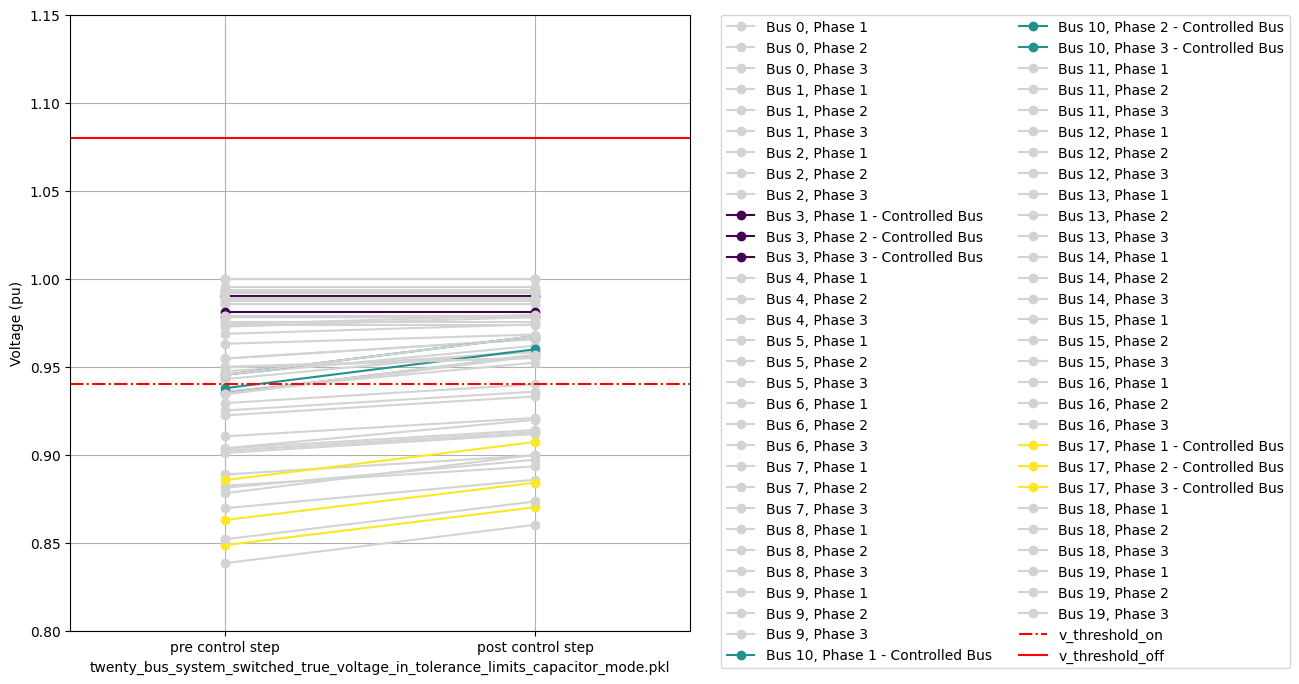

In [40]:
net = grids["twenty_bus_system_switched_false_voltage_far_below_v_threshold_on_capacitor_mode.pkl"]
net_no_control = copy.deepcopy(net)
mc.run_pf(net_no_control)
net_with_control = copy.deepcopy(net)
mc.run_pf(net_with_control, run_control=True)
print("pre control shunts closed: ", net_no_control.asymmetric_shunt.closed.tolist())
print("post control shunts closed: ", net_with_control.asymmetric_shunt.closed.tolist())
plot_control_step(net_with_control, net_no_control, ylim=(0.8, 1.15), name=name, save_string=name)